In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

In [2]:
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target)

In [3]:
print(X.shape)
print(X.isnull().sum())

(20640, 8)
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
mean = X_train.mean()
std = X_train.std()

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [6]:
X_train = X_train.values
X_test = X_test.values

y_train = y_train.values
y_test = y_test.values

# Add bias column
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [7]:
class LinearRegressionGD:

    def __init__(self, learning_rate=0.01, iterations=1000, lambda_param=0):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.lambda_param = lambda_param
        self.loss_history = []

    def predict(self, X):
        return np.dot(X, self.weights)

In [18]:
class RidgeRegression(LinearRegressionGD):

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)

        for i in range(self.iterations):
            y_pred = np.dot(X, self.weights)
            error = y_pred - y

            gradient = (1/m) * np.dot(X.T, error)

            # L2 penalty
            reg = (self.lambda_param / m) * self.weights.copy()
            reg[0] = 0
            gradient += reg

            self.weights -= self.learning_rate * gradient

            # MSE loss + L2 penalty
            loss = (1/(2*m)) * np.sum(error**2)
            loss += (self.lambda_param / (2*m)) * np.sum(self.weights[1:]**2)
            self.loss_history.append(loss)

In [9]:
class LassoRegression(LinearRegressionGD):

    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)

        for i in range(self.iterations):
            y_pred = np.dot(X, self.weights)
            error = y_pred - y

            gradient = (1/m) * np.dot(X.T, error)

            # L1 subgradient -- bias (index 0) excluded from regularization
            reg = (self.lambda_param / m) * np.sign(self.weights)
            reg[0] = 0
            gradient += reg

            self.weights -= self.learning_rate * gradient

            # MSE loss + L1 penalty (bias excluded from penalty)
            loss = (1/(2*m)) * np.sum(error**2)
            loss += (self.lambda_param / m) * np.sum(np.abs(self.weights[1:]))
            self.loss_history.append(loss)

In [10]:
ridge = RidgeRegression(learning_rate=0.01, iterations=1000, lambda_param=0.1)
ridge.fit(X_train, y_train)

lasso = LassoRegression(learning_rate=0.01, iterations=1000, lambda_param=0.1)
lasso.fit(X_train, y_train)

In [11]:
ridge_pred = ridge.predict(X_test)
lasso_pred = lasso.predict(X_test)

In [12]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - (ss_res / ss_tot)

ridge_mse = np.mean((y_test - ridge_pred) ** 2)
lasso_mse = np.mean((y_test - lasso_pred) ** 2)

ridge_r2 = r2_score(y_test, ridge_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print(f"Ridge -- MSE: {ridge_mse:.4f} | R2: {ridge_r2:.4f}")
print(f"Lasso -- MSE: {lasso_mse:.4f} | R2: {lasso_r2:.4f}")

Ridge -- MSE: 0.5672 | R2: 0.5672
Lasso -- MSE: 0.5672 | R2: 0.5672


In [13]:
feature_names = ["Bias"] + list(housing.feature_names)

weights_df = pd.DataFrame({
    "Feature": feature_names,
    "Ridge Weights": ridge.weights,
    "Lasso Weights": lasso.weights
})
print(weights_df.to_string(index=False))

   Feature  Ridge Weights  Lasso Weights
      Bias       2.071857       2.071857
    MedInc       0.828959       0.828957
  HouseAge       0.178539       0.178534
  AveRooms      -0.137936      -0.137925
 AveBedrms       0.156678       0.156663
Population       0.016816       0.016808
  AveOccup      -0.045230      -0.045223
  Latitude      -0.487043      -0.487014
 Longitude      -0.451456      -0.451427


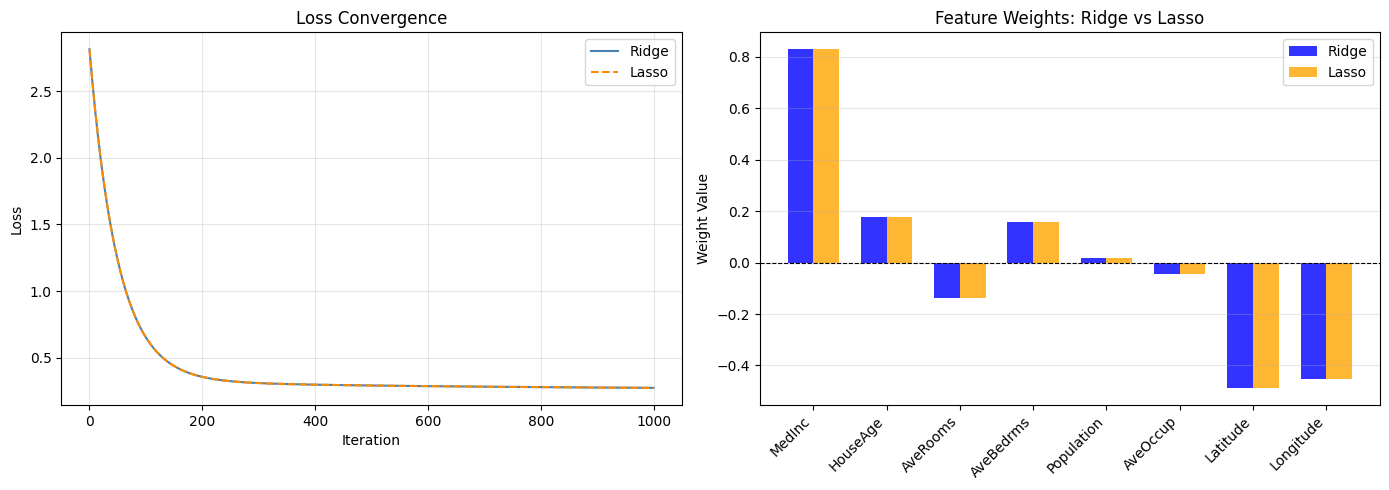

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Loss convergence:-
axes[0].plot(ridge.loss_history, label="Ridge", color="steelblue")
axes[0].plot(lasso.loss_history, label="Lasso", color="darkorange", linestyle="--")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Convergence")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Weight comparison bar chart :-
x = np.arange(len(feature_names) - 1)
width = 0.35
axes[1].bar(x - width/2, ridge.weights[1:], width, label="Ridge", color="blue", alpha=0.8)
axes[1].bar(x + width/2, lasso.weights[1:], width, label="Lasso", color="orange", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(housing.feature_names, rotation=45, ha='right')
axes[1].set_ylabel("Weight Value")
axes[1].set_title("Feature Weights: Ridge vs Lasso")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Observations:
# Ridge (L2) shrinks weights proportionally -- no weight hits exactly zero.
# Lasso (L1) applies a constant-magnitude penalty each step via sign(),
# which tends to drive smaller weights to zero (sparse solution).
# Both converge within ~200 iterations after normalization.
# R2 scores give a clearer picture of fit quality than MSE alone.